# Python for Health, Economic, and Social Science
## Lab 4 — Instructor Solution & Expansion Notes

**Course:** LCDS, Nuffield College Oxford  
**Day 4 theme:** Modelling basic kinds of data and visualising patterns with matplotlib

---

### Instructor framing for Day 4

Day 4 is the **pandas and matplotlib day** — the one that students most immediately see the value of.

The two core skills:
1. **pandas** — load, wrangle, merge, and summarise tabular data (ONS, NHS Digital, DHS, EUROSTAT output formats)
2. **matplotlib** — communicate findings through publication-ready charts

Note on Part A (JSON/requests): kept brief in this solution. The emphasis belongs on *what you do with data once you have it*, not on HTTP mechanics. In practice, most course participants will load data from CSV/Excel files rather than live API calls.

**User-requested expansion: pandas operations (appending rows, merging, groupby, reshape) — see the dedicated section at the end.**

---
## Part A: Data Access — Brief Reference

> This section is light-touch. Real datasets for this course are typically loaded via `pd.read_csv()` or `pd.read_excel()` — the API route is an optional enricher.

In [1]:
# Q1: GET request + inspect
import requests

url = "https://api.worldbank.org/v2/country/all/indicator/SP.DYN.LE00.IN?format=json&per_page=200"
try:
    response = requests.get(url, timeout=15)
    print(type(response))                  # 1. response type
    print(response.status_code)            # 2. status code
    print(response.text[:200])             # 3. first 200 chars
except requests.exceptions.RequestException as e:
    print(f"Request failed: {e}")

<class 'requests.models.Response'>
200
[{"page":1,"pages":88,"per_page":200,"total":17556,"sourceid":"2","lastupdated":"2026-02-24"},[{"indicator":{"id":"SP.DYN.LE00.IN","value":"Life expectancy at birth, total (years)"},"country":{"id":"Z


In [2]:
# Q2: Parse JSON, find first non-null record
try:
    data = response.json()
    print(type(data), len(data))
    for obs in data[1]:
        if obs.get("value") is not None:
            print(obs["country"]["value"], obs["date"], round(obs["value"], 1))
            break
except Exception as e:
    print(f"Parse error: {e}")

<class 'list'> 2
Africa Eastern and Southern 2023 65.1


In [3]:
# Q3: params= approach
base_url = "https://api.worldbank.org/v2/country/all/indicator/NY.GDP.PCAP.CD"
params   = {"format": "json", "per_page": 100}
try:
    r = requests.get(base_url, params=params, timeout=15)
    print(r.url)           # final URL with query string
    print(r.status_code)
except Exception as e:
    print(e)

https://api.worldbank.org/v2/country/all/indicator/NY.GDP.PCAP.CD?format=json&per_page=100
200


In [4]:
# Q4: Error handling with requests
try:
    r = requests.get("https://api.worldbank.org/v2/BADPATH", timeout=10)
    r.raise_for_status()         # triggers HTTPError for 4xx/5xx
    data = r.json()
except requests.exceptions.HTTPError as e:
    print(f"HTTP error: {e}")
except requests.exceptions.JSONDecodeError:
    print("Response was not valid JSON")
except requests.exceptions.RequestException as e:
    print(f"Network error: {e}")

HTTP error: 404 Client Error: Not Found for url: https://api.worldbank.org/v2/BADPATH


---
## Part B: Pandas for Policy Data

> **Core Day 4 content.** Solutions below are annotated with teaching notes and pandas expansions.

### Q5: Build a health/social/economic dashboard DataFrame

In [5]:
import pandas as pd
import numpy as np

dashboard_df = pd.DataFrame([
    {"area": "Northside",  "region_type": "Urban",    "clinic_visits": 1240, "school_absence_rate": 0.082, "median_income": 29000, "unemployment_rate": 0.118, "population": 52000},
    {"area": "Central",    "region_type": "Urban",    "clinic_visits": 980,  "school_absence_rate": 0.051, "median_income": 37000, "unemployment_rate": 0.074, "population": 61000},
    {"area": "Riverside",  "region_type": "Rural",    "clinic_visits": 1430, "school_absence_rate": 0.097, "median_income": 25000, "unemployment_rate": 0.136, "population": 47000},
    {"area": "Eastbrook",  "region_type": "Suburban", "clinic_visits": 1110, "school_absence_rate": 0.064, "median_income": 33000, "unemployment_rate": 0.091, "population": 55000},
    {"area": "Hilltown",   "region_type": "Rural",    "clinic_visits": 890,  "school_absence_rate": 0.072, "median_income": 27000, "unemployment_rate": 0.109, "population": 43000},
    {"area": "Westgate",   "region_type": "Urban",    "clinic_visits": 1350, "school_absence_rate": 0.088, "median_income": 31000, "unemployment_rate": 0.101, "population": 58000},
    {"area": "Southdowns", "region_type": "Suburban", "clinic_visits": 760,  "school_absence_rate": 0.041, "median_income": 42000, "unemployment_rate": 0.056, "population": 49000},
    {"area": "Moorfield",  "region_type": "Rural",    "clinic_visits": 1580, "school_absence_rate": 0.103, "median_income": 22000, "unemployment_rate": 0.152, "population": 38000},
])

print(dashboard_df.head())

        area region_type  clinic_visits  school_absence_rate  median_income  \
0  Northside       Urban           1240                0.082          29000   
1    Central       Urban            980                0.051          37000   
2  Riverside       Rural           1430                0.097          25000   
3  Eastbrook    Suburban           1110                0.064          33000   
4   Hilltown       Rural            890                0.072          27000   

   unemployment_rate  population  
0              0.118       52000  
1              0.074       61000  
2              0.136       47000  
3              0.091       55000  
4              0.109       43000  


>  `pd.DataFrame(list_of_dicts)` is the most intuitive constructor — each dict is one row. Other common constructors: `pd.DataFrame(dict_of_lists)` (column-first), `pd.read_csv()` (file), `pd.DataFrame(np_array, columns=[...])` (from NumPy).
>
> **Expansion — `pd.DataFrame.info()` and `pd.DataFrame.describe()`:**
```python
print(dashboard_df.info())       # column types, non-null counts
print(dashboard_df.describe())   # count, mean, std, quartiles for numerics
print(dashboard_df.dtypes)       # column data types
print(dashboard_df.shape)        # (rows, cols)
print(dashboard_df.columns.tolist())
```
> Always run `info()` immediately after loading a new dataset — null counts and wrong dtypes (e.g., income as `object` instead of `int64`) are the most common data quality issues.

### Q6: Create derived columns

In [6]:
# Q6
dashboard_df["visits_per_1000"]         = dashboard_df["clinic_visits"] / dashboard_df["population"] * 1000
dashboard_df["economic_stress_index"]   = (dashboard_df["unemployment_rate"]
                                           / dashboard_df["median_income"] * 1_000_000)

print(dashboard_df[["area", "visits_per_1000", "economic_stress_index"]].round(2))

         area  visits_per_1000  economic_stress_index
0   Northside            23.85                   4.07
1     Central            16.07                   2.00
2   Riverside            30.43                   5.44
3   Eastbrook            20.18                   2.76
4    Hilltown            20.70                   4.04
5    Westgate            23.28                   3.26
6  Southdowns            15.51                   1.33
7   Moorfield            41.58                   6.91


>  Column arithmetic in pandas is **vectorised** — it operates on the full column at once, exactly like NumPy. No loop needed. The result is a new `Series` that can be assigned to the DataFrame.
>
> **Expansion — `np.where()` for conditional column creation:**
```python

```

In [ ]:
# Binary flag: is this area high demand?
dashboard_df["high_demand"] = np.where(dashboard_df["visits_per_1000"] > 25, 1, 0)

# Three-level risk label using pd.cut (quantile-based binning):
dashboard_df["stress_band"] = pd.cut(
    dashboard_df["economic_stress_index"],
    bins=3,
    labels=["low stress", "moderate stress", "high stress"]
)
print(dashboard_df[["area", "stress_band"]])

In [ ]:
# hard copy and shallow copy! 

In [2]:
import pandas as pd 
df = pd.DataFrame({'a':[1,2,3],'b':[4,5,6]})


In [3]:
df_shallow_copy = df 

In [6]:
df_shallow_copy['a']=[2,3,4]
df_shallow_copy


,a,b
0,2,4
1,3,5
2,4,6


In [7]:
df

,a,b
0,2,4
1,3,5
2,4,6


### Q7: Filter and sort

In [7]:
# Q7
mask = (dashboard_df["school_absence_rate"] > 0.08) | (dashboard_df["unemployment_rate"] > 0.12)
flagged = dashboard_df[mask].sort_values("school_absence_rate", ascending=False)
print(flagged[["area", "school_absence_rate", "unemployment_rate"]].reset_index(drop=True))

        area  school_absence_rate  unemployment_rate
0  Moorfield                0.103              0.152
1  Riverside                0.097              0.136
2   Westgate                0.088              0.101
3  Northside                0.082              0.118


>  Boolean masks must be parenthesised when combined with `|` or `&` — Python's operator precedence makes `a > 0.08 | b > 0.12` evaluate incorrectly. Demonstrate the bug explicitly.
>
> **Expansion — `.query()` syntax for readable filters:**
```python
# Equivalent to the mask above, but more SQL-like:
flagged_q = dashboard_df.query("school_absence_rate > 0.08 or unemployment_rate > 0.12")

# With a variable threshold:
threshold = 0.08
flagged_q2 = dashboard_df.query("school_absence_rate > @threshold")
```
> `.query()` is preferred in many research codebases for its readability. The `@variable` syntax injects a Python variable into the query string.

### Q8: Groupby summaries

In [8]:
# Q8
grouped = dashboard_df.groupby("region_type")[["clinic_visits", "school_absence_rate", "median_income"]].mean()
print(grouped.round(2))

             clinic_visits  school_absence_rate  median_income
region_type                                                   
Rural               1300.0                 0.09       24666.67
Suburban             935.0                 0.05       37500.00
Urban               1190.0                 0.07       32333.33


>  `groupby` is the pandas equivalent of SQL `GROUP BY`. It returns a `DataFrameGroupBy` object; chaining `.mean()` collapses it to a summary DataFrame. Other aggregations: `.sum()`, `.count()`, `.median()`, `.std()`, `.agg({...})`.
>
> **Expansion — multiple aggregations with `.agg()`:**
```python
# Multiple summary statistics per group in one step:
summary = dashboard_df.groupby("region_type").agg(
    mean_visits     = ("clinic_visits",       "mean"),
    median_income   = ("median_income",        "median"),
    max_absence     = ("school_absence_rate",  "max"),
    area_count      = ("area",                 "count"),
).round(2)
print(summary)
```
>
> **Expansion — transform vs. agg (group-level values back to original rows):**
```python
# Add a 'group mean income' column (keeps original row count):
dashboard_df["region_mean_income"] = dashboard_df.groupby("region_type")["median_income"].transform("mean")
dashboard_df["income_vs_region_mean"] = dashboard_df["median_income"] - dashboard_df["region_mean_income"]
print(dashboard_df[["area", "region_type", "median_income", "income_vs_region_mean"]])
```

### Q9: Merge with budget data

In [9]:
# Q9
budget_df = pd.DataFrame({
    "area": ["Northside", "Central", "Riverside", "Eastbrook", "Hilltown",
             "Westgate", "Southdowns", "Moorfield"],
    "public_health_budget": [2_400_000, 2_050_000, 2_650_000, 2_200_000,
                             1_950_000, 2_350_000, 1_800_000, 2_700_000]
})

merged_df = pd.merge(dashboard_df, budget_df, on="area", how="inner")
merged_df["budget_per_visit"] = merged_df["public_health_budget"] / merged_df["clinic_visits"]

print(merged_df[["area", "public_health_budget", "budget_per_visit"]].round(0))

         area  public_health_budget  budget_per_visit
0   Northside               2400000            1935.0
1     Central               2050000            2092.0
2   Riverside               2650000            1853.0
3   Eastbrook               2200000            1982.0
4    Hilltown               1950000            2191.0
5    Westgate               2350000            1741.0
6  Southdowns               1800000            2368.0
7   Moorfield               2700000            1709.0


>  `how="inner"` keeps only areas present in *both* DataFrames. In real administrative data linkage, use `how="left"` and then inspect `NaN` rows to understand which records did *not* match — these are your linkage failures.
>
> **Expansion — merge types visualised:**
```python
# Simulate a partial budget table:
budget_partial = budget_df.iloc[:5]  # only first 5 areas

# left join: keeps all 8 dashboard rows, NaN where budget missing
left_merged = pd.merge(dashboard_df, budget_partial, on="area", how="left")
print("Left join — rows with missing budget:")
print(left_merged[left_merged["public_health_budget"].isna()][["area"]])

# outer join: all rows from both, NaN for missing sides
# useful for spotting mismatches in record linkage:
outer_merged = pd.merge(dashboard_df, budget_partial, on="area", how="outer", indicator=True)
print(outer_merged[["area", "_merge"]].tail(5))
```
> The `indicator=True` option adds a `_merge` column showing `left_only`, `right_only`, or `both` for each row — invaluable for debugging administrative data linkage.

### Q10: Save and reload

In [13]:
# print today in format YYYY-MM-DD
from datetime import datetime
print(datetime.today().strftime("%Y-%m-%d"))

2026-03-17


In [15]:
# Q10
import os
os.makedirs("../Data", exist_ok=True)

merged_df.to_csv("../Data/lab4_health_social_econ_dashboard.csv", index=False)

df_reload = pd.read_csv("../Data/lab4_health_social_econ_dashboard.csv")
print(df_reload.head())

        area region_type  clinic_visits  school_absence_rate  median_income  \
0  Northside       Urban           1240                0.082          29000   
1    Central       Urban            980                0.051          37000   
2  Riverside       Rural           1430                0.097          25000   
3  Eastbrook    Suburban           1110                0.064          33000   
4   Hilltown       Rural            890                0.072          27000   

   unemployment_rate  population  visits_per_1000  economic_stress_index  \
0              0.118       52000        23.846154               4.068966   
1              0.074       61000        16.065574               2.000000   
2              0.136       47000        30.425532               5.440000   
3              0.091       55000        20.181818               2.757576   
4              0.109       43000        20.697674               4.037037   

   public_health_budget  budget_per_visit  
0               2400000 

>  `index=False` prevents pandas from writing the row-number index as a column. If you forget this, reloaded files will have a spurious `Unnamed: 0` column — a very common beginner gotcha.
>
> **Expansion — common read_csv arguments:**
```python
# Handling common real-world CSV issues:
df = pd.read_csv(
    "../Data/health_social_econ_dashboard.csv",
    sep=',',                     # change to ';' for European CSVs
    encoding='utf-8',            # or 'latin1' for older Windows files
    na_values=['missing', 'n/a', '-', ''],  # custom missing value codes
    parse_dates=['date_col'],    # parse date columns automatically
    dtype={'area': str},         # force types where needed
)

# Handling missing data:
print(df.isna().sum())           # count NaNs per column
df_clean = df.dropna()           # drop any row with NaN
df_filled = df.fillna(df.mean(numeric_only=True))  # fill with column mean
```

---
## Part C: Matplotlib for Communication

### Q11: Line chart — monthly clinic visits

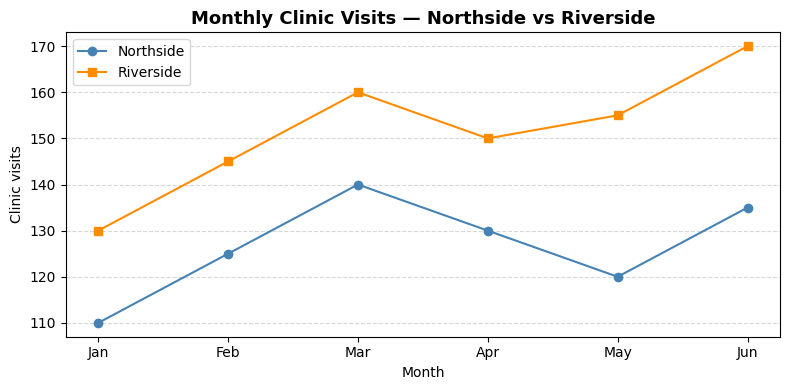

In [16]:
import matplotlib.pyplot as plt

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
northside_visits = [110, 125, 140, 130, 120, 135]
riverside_visits = [130, 145, 160, 150, 155, 170]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(months, northside_visits, marker='o', label="Northside", color="steelblue")
ax.plot(months, riverside_visits, marker='s', label="Riverside",  color="darkorange")

ax.set_title("Monthly Clinic Visits — Northside vs Riverside", fontsize=13, fontweight='bold')
ax.set_xlabel("Month")
ax.set_ylabel("Clinic visits")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

>  Always use the **object-oriented API** (`fig, ax = plt.subplots()`), not the stateful `plt.plot()` approach. The OO API composes correctly in subfigure layouts and is required for multi-panel figures.
>
> **Expansion — styling for publication:**
```python
plt.style.use('seaborn-v0_8-whitegrid')  # clean academic style
# Alternatively: 'ggplot', 'bmh', 'tableau-colorblind10'

# Add annotations for notable events:
ax.annotate('Winter surge', xy=('Feb', 145), xytext=('Feb', 155),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=9, color='gray')

# Save at high resolution for reports:
fig.savefig('../Figures/clinic_visits_trend.png', dpi=300, bbox_inches='tight')
```

### Q12: Scatter with annotation

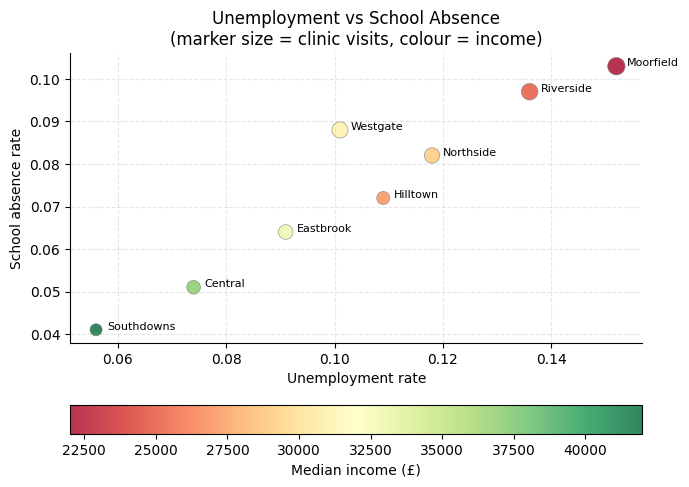

In [23]:
# Q12
fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(
    dashboard_df["unemployment_rate"],
    dashboard_df["school_absence_rate"],
    s=dashboard_df["clinic_visits"] / 10,  # marker size proportional to visits
    c=dashboard_df["median_income"],
    cmap="RdYlGn",
    alpha=0.8, edgecolors='gray', linewidths=0.5
)


for _, row in dashboard_df.iterrows():
    ax.annotate(row["area"],
                (row["unemployment_rate"] + 0.002, row["school_absence_rate"]),
                fontsize=8)

ax.set(xlabel="Unemployment rate", ylabel="School absence rate",
       title="Unemployment vs School Absence\n(marker size = clinic visits, colour = income)")
ax.grid(linestyle='--', alpha=0.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#make the cbar to the bottom being horizontal
# plt.colorbar(sc, ax=ax, label="Median income (£)")
plt.colorbar(sc, ax=ax, label="Median income (£)", orientation='horizontal', pad=0.15)

plt.tight_layout()
plt.show()

>  This scatter encodes *four variables* visually: position (2D), size, and colour. Discuss with students when this is informative vs. cluttered. For publication, usually limit to 3 visual channels; a colourblind-safe palette (e.g., `cmap='viridis'`) is preferred.
>
> **Expansion — adding a regression line:**
```python
import numpy as np
m, b = np.polyfit(dashboard_df["unemployment_rate"], dashboard_df["school_absence_rate"], 1)
x_line = np.linspace(dashboard_df["unemployment_rate"].min(), dashboard_df["unemployment_rate"].max(), 50)
ax.plot(x_line, m*x_line + b, 'k--', alpha=0.5, label=f"OLS fit (slope={m:.2f})")
ax.legend()
```

### Q13: Bar chart + histogram

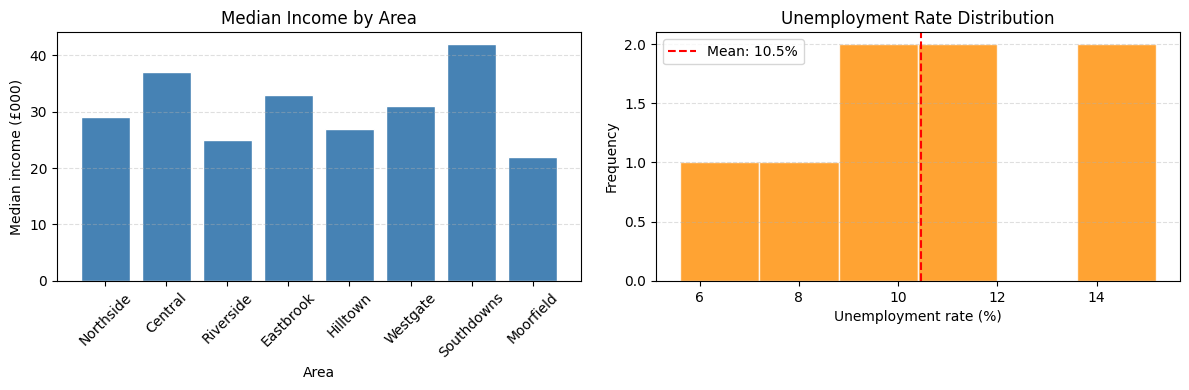

In [24]:
# Q13
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart: median income by area
ax1.bar(dashboard_df["area"], dashboard_df["median_income"] / 1000,
        color="steelblue", edgecolor="white")
ax1.set(title="Median Income by Area", xlabel="Area", ylabel="Median income (£000)")
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# Histogram: unemployment rate distribution
ax2.hist(dashboard_df["unemployment_rate"] * 100, bins=6, color="darkorange",
         edgecolor="white", alpha=0.8)
ax2.set(title="Unemployment Rate Distribution", xlabel="Unemployment rate (%)", ylabel="Frequency")
ax2.axvline(dashboard_df["unemployment_rate"].mean() * 100, color='red',
            linestyle='--', label=f"Mean: {dashboard_df['unemployment_rate'].mean()*100:.1f}%")
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

> **Expansion — seaborn integration (cleaner code for academic figures):**
```python
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Seaborn barplot includes confidence interval by default:
sns.barplot(data=dashboard_df, x="area", y="median_income",
            hue="region_type", ax=axes[0])
axes[0].set(title="Median Income by Area and Region Type")
axes[0].tick_params(axis='x', rotation=45)

# Seaborn histplot with KDE:
sns.histplot(data=dashboard_df, x="unemployment_rate", kde=True,
             color="darkorange", ax=axes[1])
axes[1].set(title="Unemployment Rate Distribution")

plt.tight_layout()
```

> why sometimes seaborn is better for academic figures: it has sensible defaults, built-in themes, and handles complex aesthetics (e.g., barplot with hue) with less code. Matplotlib offers more control but requires more lines to achieve the same polished look.

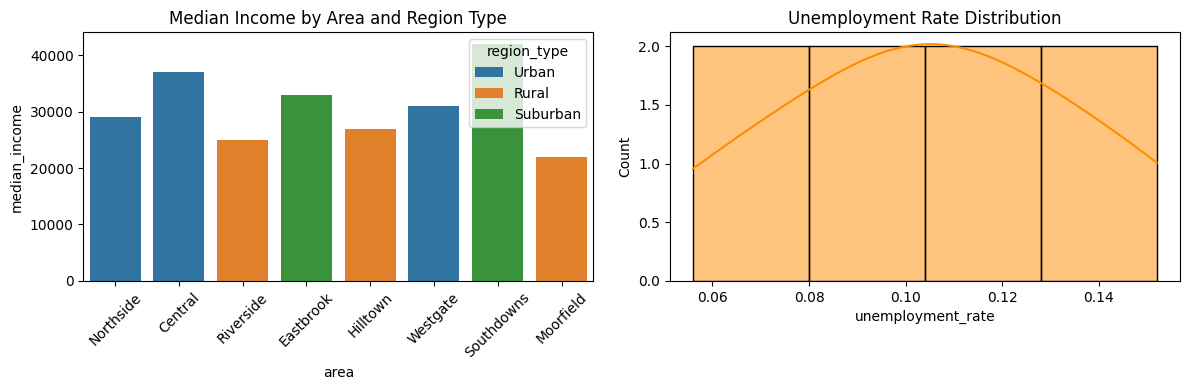

In [25]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Seaborn barplot includes confidence interval by default:
sns.barplot(data=dashboard_df, x="area", y="median_income",
            hue="region_type", ax=axes[0])
axes[0].set(title="Median Income by Area and Region Type")
axes[0].tick_params(axis='x', rotation=45)

# Seaborn histplot with KDE:
sns.histplot(data=dashboard_df, x="unemployment_rate", kde=True,
             color="darkorange", ax=axes[1])
axes[1].set(title="Unemployment Rate Distribution")

plt.tight_layout()

### Q14: Combined policy dashboard (2×2)

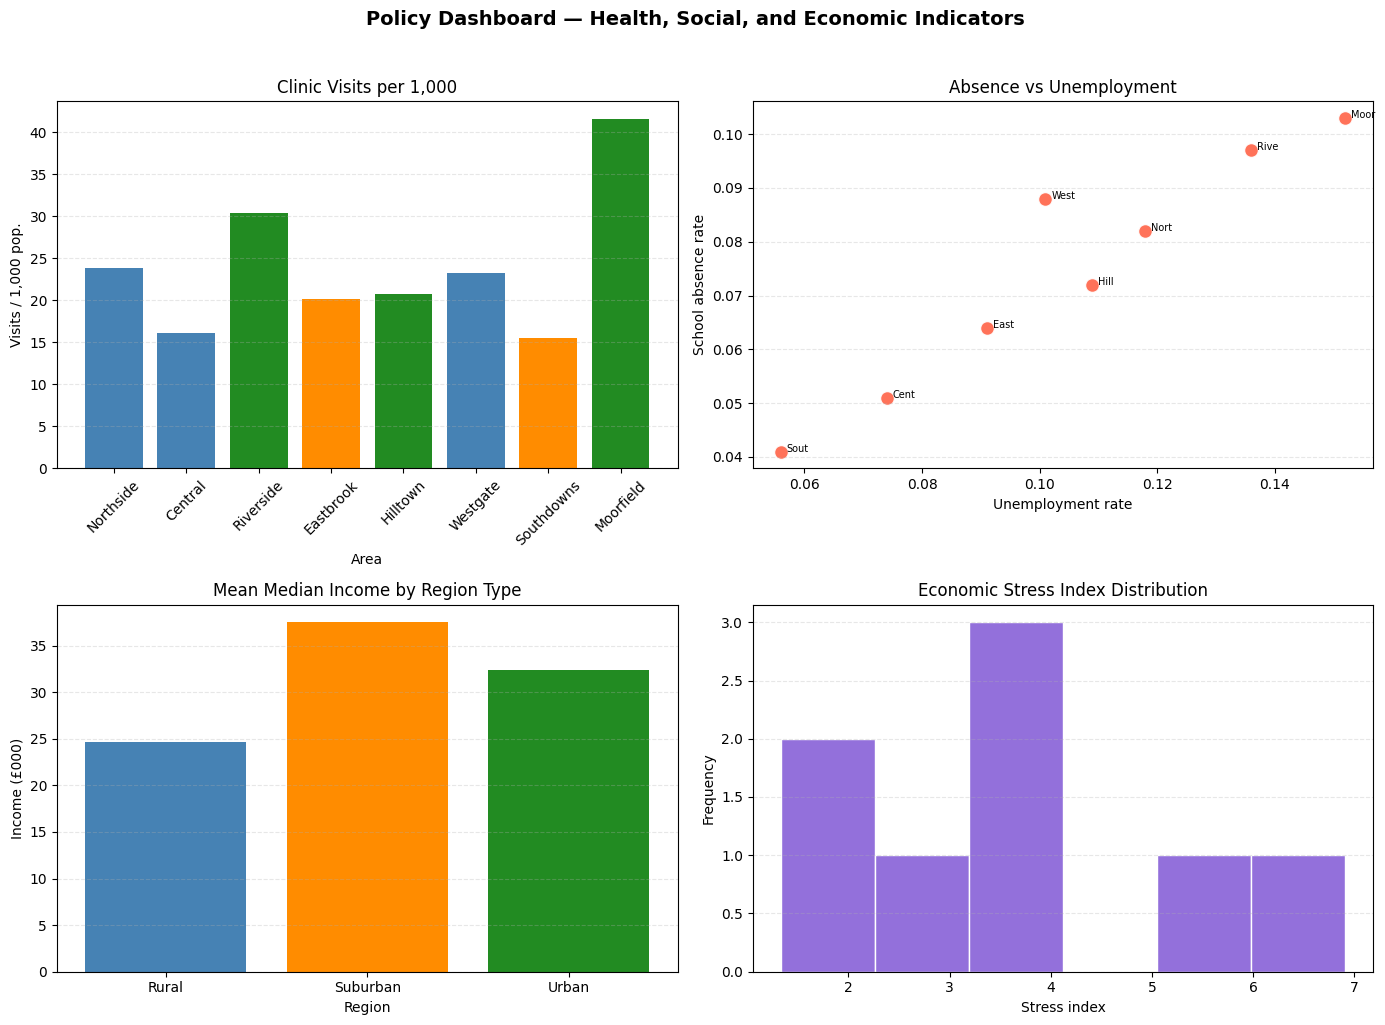

In [27]:
# Q14: 2×2 policy dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: visits per 1000 bar chart
axes[0,0].bar(dashboard_df["area"], dashboard_df["visits_per_1000"],
              color=["steelblue" if r == "Urban" else "darkorange" if r == "Suburban" else "forestgreen"
                     for r in dashboard_df["region_type"]])
axes[0,0].set(title="Clinic Visits per 1,000", xlabel="Area", ylabel="Visits / 1,000 pop.")
axes[0,0].tick_params(axis='x', rotation=45)

# Panel 2: absence vs unemployment scatter
axes[0,1].scatter(dashboard_df["unemployment_rate"], dashboard_df["school_absence_rate"],
                  s=100, color='tomato', edgecolors='white', alpha=0.9)
for _, row in dashboard_df.iterrows():
    axes[0,1].annotate(row["area"][:4],
                       (row["unemployment_rate"] + 0.001, row["school_absence_rate"]), fontsize=7)
axes[0,1].set(title="Absence vs Unemployment", xlabel="Unemployment rate", ylabel="School absence rate")

# Panel 3: median income by region type (box-like bar)
region_income = dashboard_df.groupby("region_type")["median_income"].mean()
axes[1,0].bar(region_income.index, region_income.values / 1000, color=["steelblue", "darkorange", "forestgreen"])
axes[1,0].set(title="Mean Median Income by Region Type", xlabel="Region", ylabel="Income (£000)")

# Panel 4: economic stress index distribution
axes[1,1].hist(dashboard_df["economic_stress_index"], bins=6, color="mediumpurple", edgecolor="white")
axes[1,1].set(title="Economic Stress Index Distribution", xlabel="Stress index", ylabel="Frequency")

for ax in axes.flatten():
    ax.grid(axis='y', linestyle='--', alpha=0.3)

fig.suptitle("Policy Dashboard — Health, Social, and Economic Indicators",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../../Figures/lab4_policy_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Expansion: Pandas Operations Deep Dive

> **User-requested section.** These operations are used constantly in real demographic research and are not all covered in the lab exercises.

### Appending rows to a DataFrame

In [28]:
# The old df.append() was removed in pandas 2.0.
# The correct modern approach is pd.concat().

# Method 1: append via pd.concat (most common)
new_row = pd.DataFrame([{
    "area": "Lakeside", "region_type": "Suburban",
    "clinic_visits": 1050, "school_absence_rate": 0.068,
    "median_income": 34000, "unemployment_rate": 0.095,
    "population": 46000
}])

df_extended = pd.concat([dashboard_df[["area","region_type","clinic_visits",
                                       "school_absence_rate","median_income",
                                       "unemployment_rate","population"]],
                         new_row],
                        ignore_index=True)  # resets the integer index
print(df_extended.tail(3))

         area region_type  clinic_visits  school_absence_rate  median_income  \
6  Southdowns    Suburban            760                0.041          42000   
7   Moorfield       Rural           1580                0.103          22000   
8    Lakeside    Suburban           1050                0.068          34000   

   unemployment_rate  population  
6              0.056       49000  
7              0.152       38000  
8              0.095       46000  


In [ ]:
# Method 2: build a list of rows during processing, then construct DataFrame once at the end
# (more efficient than concatenating inside a loop)

records = []
raw_input = [
    {"area": "Porthill",  "visits_raw": "920",  "income_raw": "31000"},
    {"area": "Greenlea",  "visits_raw": "1100", "income_raw": "missing"},
    {"area": "Blakewell", "visits_raw": "850",  "income_raw": "28500"},
]

for rec in raw_input:
    try:
        records.append({
            "area":          rec["area"],
            "clinic_visits": int(rec["visits_raw"]),
            "median_income": int(rec["income_raw"])
        })
    except ValueError:
        print(f"Skipping {rec['area']} — invalid value")

df_from_processing = pd.DataFrame(records)
print(df_from_processing)

> **Key rule:** Never call `pd.concat()` inside a loop (O(n²) memory copies). Always collect rows in a Python list, then call `pd.DataFrame(records)` *once* at the end. This is one of the most common pandas performance mistakes in research code.

### Pivot tables and reshaping

Pandas pivot tables in Python, created using pd.pivot_table(), summarize and aggregate data from a DataFrame, acting as a multidimensional version of groupby.

> Use pivot_table for analyzing data with duplicates or when you need aggregation (e.g., finding the mean or sum). 

>Key Parameters: index (rows), columns (columns), values (data to aggregate), aggfunc (type of aggregation, default is 'mean')



In [32]:
import pandas as pd
import numpy as np

# Sample Data
df = pd.DataFrame({
    'City': ['NYC', 'LA', 'NYC', 'LA'],
    'Product': ['Apple', 'Apple', 'Banana', 'Banana'],
    'Sales': [10, 15, 20, 25]
})

# Create Pivot Table (Sum of Sales per City and Product)
pivot = pd.pivot_table(df, values='Sales', index='City', columns='Product', aggfunc='sum')
print(pivot)


Product  Apple  Banana
City                  
LA          15      25
NYC         10      20


In [29]:
dashboard_df["high_absence"] = dashboard_df["school_absence_rate"] > 0.08
dashboard_df.head()

,area,region_type,clinic_visits,school_absence_rate,median_income,unemployment_rate,population,visits_per_1000,economic_stress_index,high_absence
0,Northside,Urban,1240,0.082,29000,0.118,52000,23.846154,4.068966,True
1,Central,Urban,980,0.051,37000,0.074,61000,16.065574,2.000000,False
2,Riverside,Rural,1430,0.097,25000,0.136,47000,30.425532,5.440000,True
3,Eastbrook,Suburban,1110,0.064,33000,0.091,55000,20.181818,2.757576,False
4,Hilltown,Rural,890,0.072,27000,0.109,43000,20.697674,4.037037,False


In [31]:
# Pivot table: mean visits_per_1000 by region_type and a risk flag

pivot = dashboard_df.pivot_table(
    values="visits_per_1000",
    index="region_type",
    columns="high_absence",
    aggfunc="mean"
).round(1)

pivot.columns = ["Normal absence", "High absence"]
pivot

,Normal absence,High absence
region_type,,
Rural,20.7,36.0
Suburban,17.8,NaN
Urban,16.1,23.6


Pandas Pivot (pivot)
Use pivot() for reshaping data without performing any aggregation. It cannot handle duplicate entries for a given row/column pair.

In [34]:
# Reshaping without aggregation
df_simple = pd.DataFrame({
    'Year': [2020, 2021],
    'NYC': [100, 150],
    'LA': [200, 250]
})
# Reorganizing the table structure
pivot_simple = df_simple.pivot(index='Year', columns='LA')

pivot_simple

NYC       
LA      200    250
Year              
2020  100.0    NaN
2021    NaN  150.0

In [37]:
# Melt: wide → long (common for plotting or time-series work)
# Example: convert multiple indicators into a single 'indicator' column
wide_df = dashboard_df[["area", "visits_per_1000", "economic_stress_index"]].copy()

wide_df.head()

,area,visits_per_1000,economic_stress_index
0,Northside,23.846154,4.068966
1,Central,16.065574,2.000000
2,Riverside,30.425532,5.440000
3,Eastbrook,20.181818,2.757576
4,Hilltown,20.697674,4.037037


In [38]:
long_df = pd.melt(
    wide_df,
    id_vars="area",
    value_vars=["visits_per_1000", "economic_stress_index"],
    var_name="indicator",
    value_name="value"
)
print(long_df.head(6))

        area        indicator      value
0  Northside  visits_per_1000  23.846154
1    Central  visits_per_1000  16.065574
2  Riverside  visits_per_1000  30.425532
3  Eastbrook  visits_per_1000  20.181818
4   Hilltown  visits_per_1000  20.697674
5   Westgate  visits_per_1000  23.275862


> **When to use melt:** seaborn's `sns.FacetGrid` and most tidy plotting libraries expect **long format** data (one row per observation). If your data is **wide** (one row per area, many indicator columns), `pd.melt()` is the transformation you need.

### Apply and map

In [40]:
# .map() — element-wise transformation of a Series (replaces values)
region_code_map = {"Urban": "U", "Suburban": "S", "Rural": "R"}
dashboard_df["region_code"] = dashboard_df["region_type"].map(region_code_map)
print(dashboard_df[["area", "region_type", "region_code"]])


         area region_type region_code
0   Northside       Urban           U
1     Central       Urban           U
2   Riverside       Rural           R
3   Eastbrook    Suburban           S
4    Hilltown       Rural           R
5    Westgate       Urban           U
6  Southdowns    Suburban           S
7   Moorfield       Rural           R


In [39]:

# .apply() — row-wise or column-wise function (flexible but slower)
def income_band(income: float) -> str:
    if income < 27000:  return "Q1"
    if income < 32000:  return "Q2"
    if income < 38000:  return "Q3"
    return "Q4"

dashboard_df["income_quartile"] = dashboard_df["median_income"].apply(income_band)
print(dashboard_df[["area", "median_income", "income_quartile"]])

         area region_type region_code
0   Northside       Urban           U
1     Central       Urban           U
2   Riverside       Rural           R
3   Eastbrook    Suburban           S
4    Hilltown       Rural           R
5    Westgate       Urban           U
6  Southdowns    Suburban           S
7   Moorfield       Rural           R
         area  median_income income_quartile
0   Northside          29000              Q2
1     Central          37000              Q3
2   Riverside          25000              Q1
3   Eastbrook          33000              Q3
4    Hilltown          27000              Q2
5    Westgate          31000              Q2
6  Southdowns          42000              Q4
7   Moorfield          22000              Q1


> **Performance tip:** `.map()` > `.apply()` for element-wise column operations. Vectorised operations (`df.col * 1.1`) > both. Reserve `.apply(axis=1)` only when you genuinely need multiple columns at once.

### String operations on columns

In [8]:
# pandas .str accessor — vectorised string methods on a column
messy_areas = pd.Series([" Northside ", "CENTRAL", "riverside", " EastBrook"])

clean_areas = messy_areas.str.strip().str.title()
print(clean_areas.tolist())

# Extract first word:
print(clean_areas.str.split().str[0].tolist())

['Northside', 'Central', 'Riverside', 'Eastbrook']
['Northside', 'Central', 'Riverside', 'Eastbrook']


---
*LCDS Oxford Python Course, March 2026 — Day 4 Lab Solution*